In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

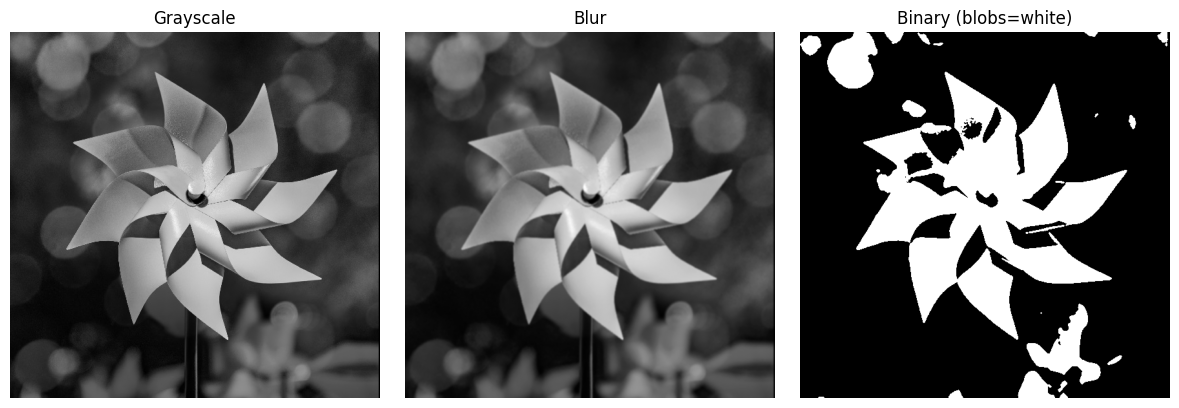

In [9]:
image_path = '../../edge_detection.png'
image_color = cv2.imread(image_path)

# Fallback: synthetic touching blobs if no input
if image_color is None:
    H, W = 256, 256
    image_color = np.zeros((H, W, 3), dtype=np.uint8)
    # Two clusters of touching circles
    centers = [(64, 64), (64, 96), (96, 80), (80, 64), (140, 160), (160, 140), (180, 160), (160, 180)]
    for c in centers:
        cv2.circle(image_color, c[::-1], 22, (255, 255, 255), -1)

gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

# Preprocess
blur = cv2.GaussianBlur(gray, (5, 5), 0)
# Otsu binarization; ensure blobs are white
_, bin0 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
if np.count_nonzero(bin0) > 0.5 * bin0.size:
    bin0 = 255 - bin0

# Morphology to clean small noise
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
opened = cv2.morphologyEx(bin0, cv2.MORPH_OPEN, kernel, iterations=1)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title('Grayscale'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(blur, cmap='gray'); plt.title('Blur'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(opened, cmap='gray'); plt.title('Binary (blobs=white)'); plt.axis('off')
plt.tight_layout(); plt.show()

binary = opened

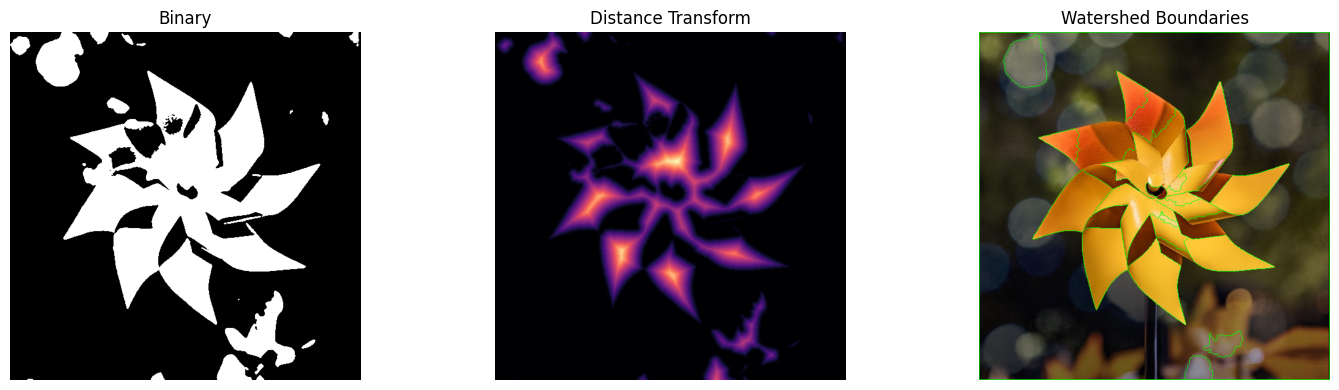

In [10]:
# Sure background by dilating binary
sure_bg = cv2.dilate(binary, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)), iterations=2)

# Distance transform on binary foreground
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
# Threshold peaks to get sure foreground markers (tighter threshold for touching blobs)
fg_thresh = 0.5 * dist_transform.max()
_, sure_fg = cv2.threshold(dist_transform, fg_thresh, 255, 0)
sure_fg = sure_fg.astype(np.uint8)

unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
num_labels, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1  # background as 1
markers[unknown == 255] = 0

# Watershed over the original color image for better gradient cues
markers = cv2.watershed(image_color.copy(), markers)

# Boundaries are -1
result = image_color.copy()
result[markers == -1] = [0, 255, 0]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.imshow(binary, cmap='gray'); plt.title('Binary'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(dist_transform, cmap='magma'); plt.title('Distance Transform'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); plt.title('Watershed Boundaries'); plt.axis('off')
plt.tight_layout(); plt.show()

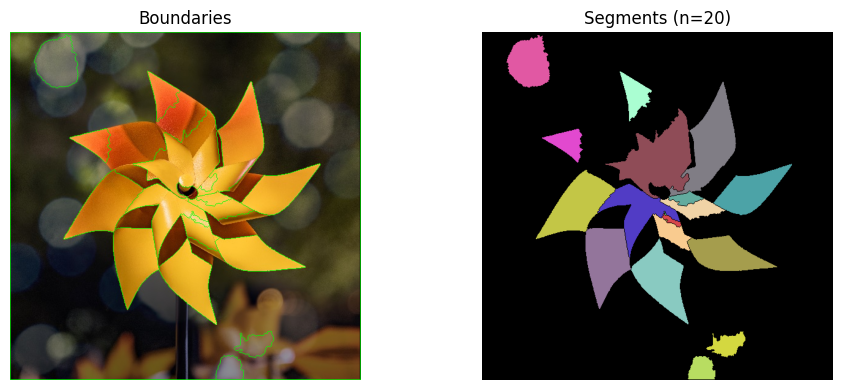

In [11]:
# Vectorized color labeling for segments (exclude -1 boundaries and 1 background)
seg = markers.copy()
mask_segments = (seg > 1)
seg_ids = np.unique(seg[mask_segments])
num_blobs = len(seg_ids)

# Assign random colors per segment label
colored_segments = np.zeros((seg.shape[0], seg.shape[1], 3), dtype=np.uint8)
if num_blobs > 0:
    rng = np.random.default_rng(42)
    color_map = {int(l): rng.integers(60, 255, size=3, dtype=np.uint8) for l in seg_ids}
    flat = colored_segments.reshape(-1, 3)
    seg_flat = seg.reshape(-1)
    for l in seg_ids:
        flat[seg_flat == l] = color_map[int(l)]

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); plt.title('Boundaries'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(colored_segments, cv2.COLOR_BGR2RGB)); plt.title(f'Segments (n={num_blobs})'); plt.axis('off')
plt.tight_layout(); plt.show()